# Tree-Based Models — Random Forest & XGBoost

Extension to the regularized-models comparison: fit `RandomForestRegressor` and `XGBRegressor` for all 6 proposal targets and compare their test R² against the linear/Ridge/Lasso baselines.

Outputs:
- `outputs/tree_results.csv` — val + test metrics for both models, all targets
- `outputs/tree_test_results.csv` — test-only subset (consumed by `final.ipynb`)
- `outputs/tree_feature_importances.csv` — per-target, per-model feature importances
- `outputs/tree_predicted_vs_actual.png` — 2×3 scatter grid (best tree model per target)
- `outputs/tree_feature_importance_heatmap.png` — RF vs XGB importance heatmap

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

pd.set_option("display.max_columns", 100)
np.random.seed(42)

In [2]:
SRC_PATH = Path.cwd() / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from project_utils import compute_regression_metrics, ensure_dir, ensure_processed_data

In [3]:
data_parts = ensure_processed_data(data_dir="data", processed_dir="data/processed", random_state=42)
train_df = data_parts["train"]
val_df = data_parts["val"]
test_df = data_parts["test"]
print("Train/Val/Test shapes:", train_df.shape, val_df.shape, test_df.shape)

Train/Val/Test shapes: (91259, 14) (19556, 14) (19556, 14)


In [4]:
proposal_targets = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "loudness",
    "tempo",
]
available_targets = [t for t in proposal_targets if t in train_df.columns]
available_targets

['danceability', 'energy', 'valence', 'acousticness', 'loudness', 'tempo']

In [5]:
def build_tree_models():
    return {
        "random_forest": RandomForestRegressor(
            n_estimators=200,
            max_depth=20,
            min_samples_leaf=5,
            n_jobs=-1,
            random_state=42,
        ),
        "xgboost": XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            tree_method="hist",
            random_state=42,
            n_jobs=-1,
        ),
    }

In [6]:
rows = []
importance_records = []

for target in available_targets:
    feature_cols = [c for c in train_df.columns if c != target]
    X_train, y_train = train_df[feature_cols], train_df[target]
    X_val, y_val = val_df[feature_cols], val_df[target]
    X_test, y_test = test_df[feature_cols], test_df[target]

    for model_name, model in build_tree_models().items():
        fitted = model.fit(X_train, y_train)

        for split_name, X_split, y_split in [("validation", X_val, y_val), ("test", X_test, y_test)]:
            y_pred = fitted.predict(X_split)
            metrics = compute_regression_metrics(y_split, y_pred)
            rows.append({
                "target": target,
                "model": model_name,
                "split": split_name,
                **metrics,
                "n_features": len(feature_cols),
            })

        importances = fitted.feature_importances_
        for feat, imp in zip(feature_cols, importances):
            importance_records.append({
                "target": target,
                "model": model_name,
                "feature": feat,
                "importance": float(imp),
            })

results_df = pd.DataFrame(rows)
importance_df = pd.DataFrame(importance_records)
results_df.head()

,target,model,split,mse,mae,r2,n_features
0,danceability,random_forest,validation,0.012574,0.087134,0.643670,13
1,danceability,random_forest,test,0.012591,0.087065,0.642839,13
2,danceability,xgboost,validation,0.011911,0.085236,0.662470,13
3,danceability,xgboost,test,0.011874,0.084961,0.663182,13
4,energy,random_forest,validation,0.010692,0.077567,0.842819,13


In [7]:
outputs_dir = ensure_dir("outputs")
results_path = outputs_dir / "tree_results.csv"
test_results_path = outputs_dir / "tree_test_results.csv"
importances_path = outputs_dir / "tree_feature_importances.csv"

results_df.to_csv(results_path, index=False)
results_df[results_df["split"] == "test"].to_csv(test_results_path, index=False)
importance_df.to_csv(importances_path, index=False)

print(f"Saved -> {results_path}")
print(f"Saved -> {test_results_path}")
print(f"Saved -> {importances_path}")

Saved -> outputs/tree_results.csv
Saved -> outputs/tree_test_results.csv
Saved -> outputs/tree_feature_importances.csv


In [8]:
test_results = results_df[results_df["split"] == "test"].copy()
tree_r2_pivot = test_results.pivot(index="target", columns="model", values="r2")
tree_r2_pivot

model,random_forest,xgboost
target,,
acousticness,0.658143,0.664970
danceability,0.642839,0.663182
energy,0.842731,0.850077
loudness,0.855171,0.858608
tempo,0.131657,0.129418
valence,0.437910,0.450712


In [9]:
tree_best_by_target = (
    test_results.sort_values("r2", ascending=False)
    .groupby("target", as_index=False)
    .first()
    .sort_values("r2", ascending=False)
)
tree_best_by_target

,target,model,split,mse,mae,r2,n_features
3,loudness,xgboost,test,6.007386,1.753105,0.858608,13
2,energy,xgboost,test,0.010176,0.076421,0.850077,13
0,acousticness,xgboost,test,0.040201,0.149082,0.664970,13
1,danceability,xgboost,test,0.011874,0.084961,0.663182,13
5,valence,xgboost,test,0.036810,0.152694,0.450712,13
4,tempo,random_forest,test,771.735949,22.022227,0.131657,13


## Predicted vs Actual — Best Tree Model per Target

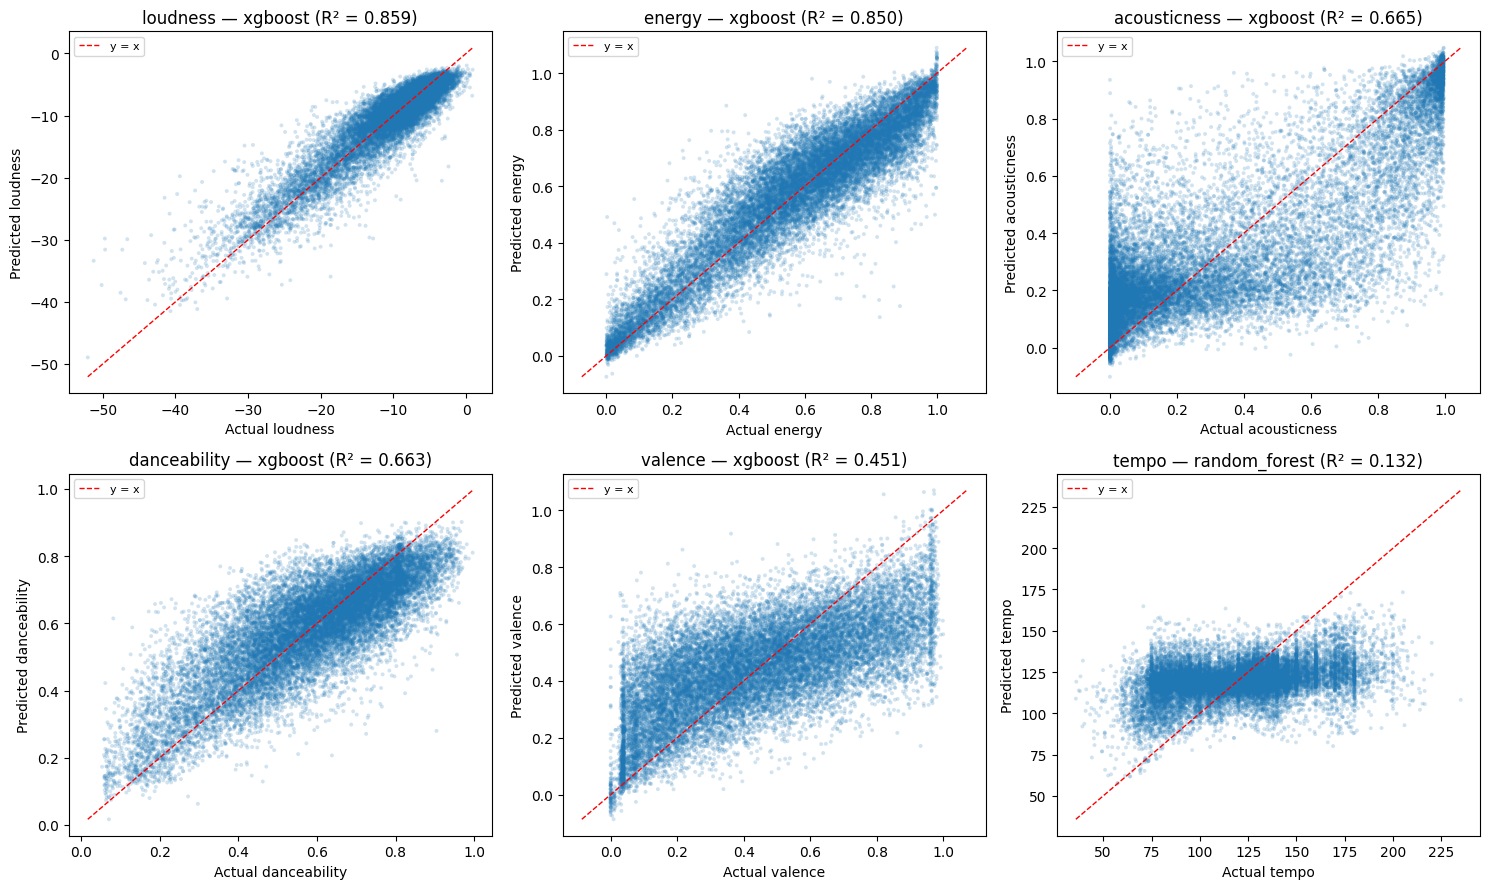

Saved -> outputs/tree_predicted_vs_actual.png


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, (_, row) in zip(axes, tree_best_by_target.iterrows()):
    target = row["target"]
    model_name = row["model"]
    feature_cols = [c for c in train_df.columns if c != target]
    X_train, y_train = train_df[feature_cols], train_df[target]
    X_test, y_test = test_df[feature_cols], test_df[target]

    model = build_tree_models()[model_name]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    ax.scatter(y_test, y_pred, alpha=0.2, s=8, edgecolors="none")
    lo = float(min(y_test.min(), y_pred.min()))
    hi = float(max(y_test.max(), y_pred.max()))
    ax.plot([lo, hi], [lo, hi], "r--", linewidth=1, label="y = x")
    ax.set_xlabel(f"Actual {target}")
    ax.set_ylabel(f"Predicted {target}")
    ax.set_title(f"{target} — {model_name} (R² = {row['r2']:.3f})")
    ax.legend(loc="best", fontsize=8)

plt.tight_layout()
scatter_path = outputs_dir / "tree_predicted_vs_actual.png"
plt.savefig(scatter_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved -> {scatter_path}")

## Feature Importance Heatmap (RF vs XGBoost)

Tree-model importances are non-negative and sum to 1 per fit, so they're directly comparable across targets within a single model. Stacked here as two side-by-side heatmaps.

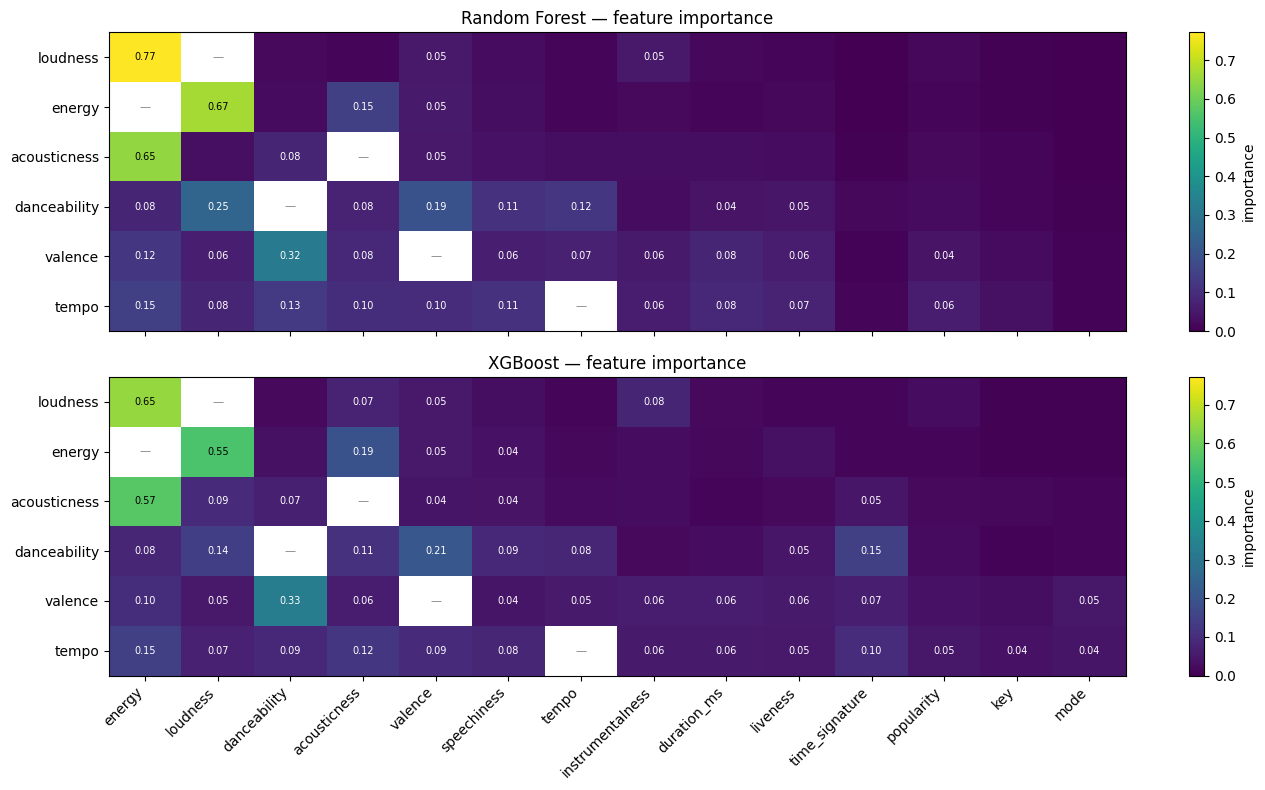

Saved -> outputs/tree_feature_importance_heatmap.png


In [11]:
target_order = tree_best_by_target["target"].tolist()
all_features = sorted(importance_df["feature"].unique())

rf_pivot = (importance_df[importance_df["model"] == "random_forest"]
            .pivot(index="target", columns="feature", values="importance")
            .reindex(index=target_order, columns=all_features))
xgb_pivot = (importance_df[importance_df["model"] == "xgboost"]
             .pivot(index="target", columns="feature", values="importance")
             .reindex(index=target_order, columns=all_features))

# Sort columns by mean importance across models so the most-impactful features land on the left.
mean_imp = pd.concat([rf_pivot, xgb_pivot]).mean(axis=0).sort_values(ascending=False)
rf_pivot = rf_pivot.reindex(columns=mean_imp.index)
xgb_pivot = xgb_pivot.reindex(columns=mean_imp.index)

vmax = float(np.nanmax(np.maximum(rf_pivot.values, xgb_pivot.values)))
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for ax, pivot, title in zip(axes, [rf_pivot, xgb_pivot], ["Random Forest", "XGBoost"]):
    im = ax.imshow(pivot.values, cmap="viridis", vmin=0, vmax=vmax, aspect="auto")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title(f"{title} — feature importance")
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            if pd.isna(v):
                ax.text(j, i, "—", ha="center", va="center", fontsize=8, color="gray")
            elif v > vmax * 0.05:
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                        color="white" if v < vmax * 0.5 else "black")
    fig.colorbar(im, ax=ax, label="importance")
axes[-1].set_xticks(range(len(rf_pivot.columns)))
axes[-1].set_xticklabels(rf_pivot.columns, rotation=45, ha="right")
plt.tight_layout()
heatmap_path = outputs_dir / "tree_feature_importance_heatmap.png"
plt.savefig(heatmap_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved -> {heatmap_path}")

## Next Notebook
Run [`final.ipynb`](final.ipynb) — it now reads `tree_test_results.csv` so the model-vs-target comparison includes Random Forest and XGBoost alongside the linear/regularized baselines.